## Imports

In [1]:
from fastmcp import Client

## List Available Tools

In [2]:
client = Client("http://localhost:8001/mcp")

In [3]:
async with client:
    tools = await client.list_tools()

In [4]:
print(tools)

[Tool(name='get_sensor_catalog', title=None, description='Return the sensor catalog for a given machine (tags, thresholds, units, fault correlations).', inputSchema={'additionalProperties': False, 'properties': {'machine': {'type': 'string'}}, 'required': ['machine'], 'type': 'object'}, outputSchema={'properties': {'result': {'type': 'string'}}, 'required': ['result'], 'type': 'object', 'x-fastmcp-wrap-result': True}, icons=None, annotations=None, meta={'fastmcp': {'tags': []}}, execution=None), Tool(name='get_sensor_readings', title=None, description='Return sensor readings for a machine within a time window.', inputSchema={'additionalProperties': False, 'properties': {'machine': {'type': 'string', 'description': "Machine ID (e.g. 'HX-200')."}, 'start_date': {'type': 'string', 'description': "Start of window (ISO format, e.g. '2024-12-01')."}, 'end_date': {'type': 'string', 'description': "End of window (ISO format, e.g. '2024-12-18')."}, 'tag': {'anyOf': [{'type': 'string'}, {'type':

## Execute Tools

In [5]:
async with client:
    result = await client.call_tool("get_sensor_catalog", {"machine": "HX-200"})

In [6]:
print(result.content[0].text)

| sensor_id   | tag            | sensor_name          | unit   |   nominal_value |   warn_lo |   warn_hi |   crit_lo |   crit_hi | fault_correlation   | active   |
|:------------|:---------------|:---------------------|:-------|----------------:|----------:|----------:|----------:|----------:|:--------------------|:---------|
| SNS-0005    | HX-200-DP-201  | Filter Delta-P       | bar    |             1.2 |         0 |       2.5 |         0 |         4 | E-005               | True     |
| SNS-0009    | HX-200-IA-101  | Motor Current        | A      |            18   |        10 |      21   |         5 |        25 | E-003               | True     |
| SNS-0007    | HX-200-LS-101  | Oil Level            | mm     |           650   |       400 |     800   |       300 |       900 | E-008               | True     |
| SNS-0008    | HX-200-POS-401 | Cylinder Position    | mm     |             0   |        -2 |       2   |        -5 |         5 | E-004               | True     |
| SNS-0001    | 

## MCP Tool Calling with Langchain

In [9]:
from langchain_mcp_adapters.client import MultiServerMCPClient

In [ ]:
client = MultiServerMCPClient({
    "db-mcp-server": {
        "url": "http://localhost:8001/mcp",
        "transport": "http"
    }
})

In [11]:
mcp_tool = await client.get_tools()
print(mcp_tool)

[StructuredTool(name='get_sensor_catalog', description='Return the sensor catalog for a given machine (tags, thresholds, units, fault correlations).', args_schema={'additionalProperties': False, 'properties': {'machine': {'type': 'string'}}, 'required': ['machine'], 'type': 'object'}, metadata={'_meta': {'fastmcp': {'tags': []}}}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x10648f420>), StructuredTool(name='get_sensor_readings', description='Return sensor readings for a machine within a time window.', args_schema={'additionalProperties': False, 'properties': {'machine': {'type': 'string', 'description': "Machine ID (e.g. 'HX-200')."}, 'start_date': {'type': 'string', 'description': "Start of window (ISO format, e.g. '2024-12-01')."}, 'end_date': {'type': 'string', 'description': "End of window (ISO format, e.g. '2024-12-18')."}, 'tag': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'descripti

In [12]:
result = await mcp_tool[0].ainvoke({"machine": "HX-200"})

In [15]:
print(result[0]['text'])

| sensor_id   | tag            | sensor_name          | unit   |   nominal_value |   warn_lo |   warn_hi |   crit_lo |   crit_hi | fault_correlation   | active   |
|:------------|:---------------|:---------------------|:-------|----------------:|----------:|----------:|----------:|----------:|:--------------------|:---------|
| SNS-0005    | HX-200-DP-201  | Filter Delta-P       | bar    |             1.2 |         0 |       2.5 |         0 |         4 | E-005               | True     |
| SNS-0009    | HX-200-IA-101  | Motor Current        | A      |            18   |        10 |      21   |         5 |        25 | E-003               | True     |
| SNS-0007    | HX-200-LS-101  | Oil Level            | mm     |           650   |       400 |     800   |       300 |       900 | E-008               | True     |
| SNS-0008    | HX-200-POS-401 | Cylinder Position    | mm     |             0   |        -2 |       2   |        -5 |         5 | E-004               | True     |
| SNS-0001    | 

## Agent with MCP tools

In [77]:
from typing import Any, Annotated, List, Union
from operator import add

import cohere

from openai import OpenAI

from pydantic import BaseModel, Field

from jinja2 import Template

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import AIMessage, ToolMessage, SystemMessage

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langsmith import traceable

from qdrant_client import QdrantClient, models

from IPython.display import Image, display
from utils.utils import display_graph

## Configuration

In [78]:
# --- Clients (reuse existing) ---
OPENAI_CLIENT = OpenAI()
QDRANT_CLIENT = QdrantClient(host="localhost", port=6333)
MCP_CLIENT = MultiServerMCPClient({
    "db-mcp-server": {
        "url": "http://localhost:8001/mcp",
        "transport": "http"
    }
})

MCP_TOOLS = await MCP_CLIENT.get_tools()


# --- Models & Collections ---
CM_COLLECTION = "cm_interventions_hybrid"
PROC_COLLECTION = "procedures_hybrid"
EMBEDDING_MODEL = "text-embedding-3-small"
KEYWORD_MODEL = "bm25"
GENERATION_MODEL = "gpt-4.1-mini"

## State & Data Models

In [79]:
class UsedReference(BaseModel):
    source_type: str = Field(description="Type of source: 'intervention', 'procedure', 'sensor', or 'component_life'")
    id: str = Field(description="Identifier — intervention ID (e.g. INT-2023-0070), procedure section, sensor tag, or component ID")
    machine: str = Field(default="", description="Machine ID (e.g. HX-200)")
    detail: str = Field(default="", description="Short summary: intervention summary, procedure title, sensor reading, or component condition")

class FinalResponse(BaseModel):
    answer: str = Field(description="Answer to the question")
    references: list[UsedReference] = Field(description="List of all sources used to answer the question")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: Annotated[List[UsedReference], add] = []

class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str

## Tools

Wrap all retrieval and sensor functions as LangChain tools.

In [80]:
@traceable(name="embed_query", run_type="embedding")
def _embed_text(text: str) -> list[float]:
    response = OPENAI_CLIENT.embeddings.create(input=text, model=EMBEDDING_MODEL)
    return response.data[0].embedding


@traceable(name="cm_data_retrieval", run_type="retriever")
def _retrieve_cm(query: str, top_k: int = 5) -> list[dict]:
    query_vector = _embed_text(query)
    search_results = QDRANT_CLIENT.query_points(
        collection_name=CM_COLLECTION,
        prefetch=[
            models.Prefetch(query=query_vector, using=EMBEDDING_MODEL, limit=top_k // 2),
            models.Prefetch(query=models.Document(text=query, model="qdrant/" + KEYWORD_MODEL), using=KEYWORD_MODEL, limit=top_k // 2),
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1, 1])),
        limit=top_k,
    ).points
    return [{"id": point.id, "payload": point.payload, "score": point.score} for point in search_results]


@traceable(name="proc_data_retrieval", run_type="retriever")
def _retrieve_procedures(query: str, top_k: int = 5) -> list[dict]:
    query_vector = _embed_text(query)
    search_results = QDRANT_CLIENT.query_points(
        collection_name=PROC_COLLECTION,
        prefetch=[
            models.Prefetch(query=query_vector, using=EMBEDDING_MODEL, limit=top_k // 2),
            models.Prefetch(query=models.Document(text=query, model="qdrant/" + KEYWORD_MODEL), using=KEYWORD_MODEL, limit=top_k // 2),
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1, 1])),
        limit=top_k,
    ).points
    return [{"id": point.id, "payload": point.payload, "score": point.score} for point in search_results]


@traceable(name="format_cm_context", run_type="prompt")
def _format_cm_context(results: list[dict]) -> str:
    context = ""
    for result in results:
        payload = result["payload"]
        context += (
            f"ID: {payload.get('id', 'N/A')}\n"
            f"Machine: {payload.get('machine', 'N/A')}\n"
            f"Date: {payload.get('date_start', 'N/A')}\n"
            f"Summary: {payload.get('summary', 'N/A')}\n"
            + "-" * 40 + "\n"
        )
    return context


@traceable(name="format_proc_context", run_type="prompt")
def _format_proc_context(results: list[dict]) -> str:
    context = ""
    for result in results:
        payload = result["payload"]
        context += (
            f"File: {payload.get('file_name', 'N/A')}\n"
            f"Section: {payload.get('section_title', 'N/A')}\n"
            f"Context: {payload.get('context', 'N/A')}\n"
            f"Text: {payload.get('text', 'N/A')}\n"
            + "-" * 40 + "\n"
        )
    return context


# --- LangChain Tools ---

@tool
def get_formatted_cm_context(query: str, top_n: int = 10) -> str:
    """Retrieve past corrective maintenance intervention records for a query.

    Searches the maintenance history database using hybrid retrieval (dense + BM25).
    Use this for questions about past failures, root causes, repair actions, and intervention history.

    Args:
        query: The search query string describing the issue or machine.
        top_n: Number of results to retrieve. Defaults to 10.

    Returns:
        A formatted string with intervention records showing ID, machine, date, and summary.
    """
    results = _retrieve_cm(query, top_k=top_n)
    return _format_cm_context(results)


@tool
def get_formatted_procedure_context(query: str, top_n: int = 10) -> str:
    """Retrieve troubleshooting procedure documentation for a query.

    Searches the procedures knowledge base (extracted from machine troubleshooting PDFs).
    Use this for questions about diagnostic steps, fault codes, PPE, emergency procedures, and standard repair procedures.

    Args:
        query: The search query string describing the fault or procedure needed.
        top_n: Number of results to retrieve. Defaults to 10.

    Returns:
        A formatted string with procedure chunks showing file, section, context, and text.
    """
    results = _retrieve_procedures(query, top_k=top_n)
    return _format_proc_context(results)


In [81]:
ALL_TOOLS = [
    get_formatted_cm_context,
    get_formatted_procedure_context,
    *MCP_TOOLS
]

## Agent Node & Intent Router

In [82]:
## Module-level LLM setup

_llm = ChatOpenAI(model=GENERATION_MODEL)
_llm_with_tools = _llm.bind_tools(ALL_TOOLS, tool_choice="auto")
_llm_structured = _llm.with_structured_output(FinalResponse)
_llm_intent = _llm.with_structured_output(IntentRouterResponse)

In [83]:
def tool_router(state: State) -> str:
    if state.final_answer:
        return "end"
    if state.iteration > 3:
        return "end"
    last_message = state.messages[-1]
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "tools"
    return "end"


@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": GENERATION_MODEL}
)
def agent_node(state: State) -> dict:

    prompt = """You are a maintenance assistant with access to multiple data sources:

1. **Maintenance history** (get_formatted_cm_context): past corrective maintenance interventions — use for root cause analysis, failure patterns, and repair history.
2. **Troubleshooting procedures** (get_formatted_procedure_context): official diagnostic steps from machine manuals — use for fault code procedures, step-by-step diagnostics, PPE, and emergency procedures.
3. **Sensor catalog** (get_sensor_catalog_tool): list of sensors on a machine with thresholds — use to understand what sensors exist and their normal ranges.
4. **Sensor readings** (get_sensor_readings_tool): recent sensor values and status — use to check current machine condition and trends.
5. **Remaining useful life** (get_remaining_life_tool): component RUL and condition — use to assess component health and plan replacements.

## Instructions

- Use the available tools to retrieve relevant data before answering.
- Always call at least one tool in the first interaction. An answer without tool_calls on turn 1 is invalid.
- If the question spans multiple topics (e.g. past failures AND current sensor data), make separate tool calls for each.
- Any request that needs remaining life time or sensors, you need a specific time window (e.g 2024-01-01 and 2024-01-10)
- NEVER say what you are about to do. Act immediately — just call the tools.
- After receiving tool results, synthesize a clear answer for the technician.
- If the context does not contain relevant records, say so explicitly.
- Cite sources inline: intervention IDs as (INT-2023-0907), procedures as (Proc: section title), sensor tags as (Sensor: TAG), components as (RUL: component).
- End the answer with a "References:" section listing all cited sources.
- Populate the `references` field with all sources used. Each reference must have:
  - `source_type`: one of 'intervention', 'procedure', 'sensor', 'component_life'
  - `id`: the identifier (intervention ID, section title, sensor tag, or component ID)
  - `machine`: the machine ID
  - `detail`: a short summary of what was found
"""

    system_message = SystemMessage(content=prompt)
    messages = state.messages

    has_tool_results = any(isinstance(m, ToolMessage) for m in messages)
    last_message = messages[-1] if messages else None
    last_has_pending_tool_calls = last_message is not None and hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0

    if has_tool_results and not last_has_pending_tool_calls:
        response: FinalResponse = _llm_structured.invoke([system_message, *messages])
        return {
            "messages": [AIMessage(content=response.answer)],
            "iteration": state.iteration + 1,
            "answer": response.answer,
            "final_answer": True,
            "references": response.references,
        }
    else:
        response = _llm_with_tools.invoke([system_message, *messages])
        return {
            "messages": [response],
            "iteration": state.iteration + 1,
            "answer": "",
            "final_answer": False,
            "references": [],
        }

In [84]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": GENERATION_MODEL}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a maintenance assistant that answers questions about equipment interventions, failure history, sensor data, and troubleshooting procedures.

    ## Instructions

    - Determine whether the question is about machines, components, failures, maintenance interventions, sensor readings, component life, or troubleshooting.
    - Questions about fault codes, symptoms, repair history, root causes, scheduled maintenance, component replacements, sensor values, and diagnostics are relevant.
    - Questions about HR policies, personal advice, or unrelated topics are not relevant.

    ## Examples

    Question: "What caused the hydraulic pump failure on HX-350?"
    Relevant: yes

    Question: "What are the current sensor readings for HX-200?"
    Relevant: yes

    Question: "What's the remaining life of the pump bearing on CB-200?"
    Relevant: yes

    Question: "What's the weather like today?"
    Relevant: no - not related to maintenance

    Question: "Can you help me write an email?"
    Relevant: no - not related to maintenance
    """

    response: IntentRouterResponse = _llm_intent.invoke([
        SystemMessage(content=prompt_template),
        *state.messages
    ])

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }


def intent_router_conditional_edges(state: State) -> str:
    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

## Build Graph

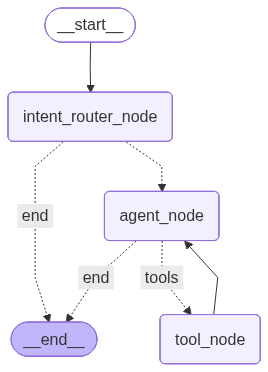

In [85]:
workflow = StateGraph(State)

tool_node = ToolNode(ALL_TOOLS)

workflow.add_node("tool_node", tool_node)
workflow.add_node("intent_router_node", intent_router_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {"agent_node": "agent_node", "end": END}
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {"tools": "tool_node", "end": END}
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()
display_graph(graph)

## Test

For multi turn conversation, we need AsyncPostgres Checkpointer.

In [86]:
initial_state = {
    "messages": [{"role": "user", "content": "The HX-200 hydraulic press is showing high oil temperature warnings. Check the current sensor readings, the remaining life of its components, and look up the troubleshooting procedure for overtemperature faults. Also check if there have been similar past interventions."}],
}

result = await graph.ainvoke(initial_state)

In [87]:
print(result['answer'])

There are currently no recent sensor readings for the oil temperature on the HX-200 hydraulic press between June 1 and June 19, 2024. However, the remaining useful life of several components related to the hydraulic system shows multiple overdue replacements, including the pump bearing set, pressure sensor outlet, pressure relief valve, and solenoid coil B. The accumulator bladder, hydraulic pump, and cylinder seal kit are all at their end of life and should be replaced at the next opportunity to prevent faults. Notably, the oil cooler and temperature sensor have good remaining life.

The troubleshooting procedure for the high oil temperature fault (E-002) on HX-200 includes monitoring the temperature sensor TS-101, checking that the cooling fan HE-501 is operating and airflow is unobstructed, inspecting and cleaning cooler fins, checking ambient temperature (should be below 40°C), and verifying cycle time to allow cooling. If the oil temperature exceeds 75°C, the machine should be sto